#import libraries and data

In [183]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("train_with_lags_2.csv")   # your cleaned dataset
df = df.sort_values("date_id")         # important for time-series modeling

# split up training and validation sets

In [184]:
TARGET = "forward_returns"

feature_cols = [c for c in df.columns
                if c not in ["date_id", TARGET, "risk_free_rate", "market_forward_excess_returns"]]

# LGBM traning

In [185]:
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df[TARGET]

# Splitting the data into training and validation sets. Adjust test_size as needed.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False) # shuffle=False is important for time-series data

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (7216, 114)
y_train shape: (7216,)
X_val shape: (1805, 114)
y_val shape: (1805,)


In [186]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_val,   label=y_val)


model = lgb.LGBMRegressor(
    objective="huber",
    alpha=0.9,         # delta-like parameter (between 0 and 1); 0.9 works for slightly outlier-prone targets
    boosting_type="gbdt",
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=1000,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5
)

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[10]	training's rmse: 0.0101478	valid_1's rmse: 0.0110847


In [187]:
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=10000000000000000),
        lgb.log_evaluation(period=100)  # prints every 100 rounds
    ]
)

Training until validation scores don't improve for 10000000000000000 rounds
[100]	valid_0's rmse: 0.01161	valid_0's huber: 6.73962e-05
[200]	valid_0's rmse: 0.0119011	valid_0's huber: 7.08185e-05
[300]	valid_0's rmse: 0.0120718	valid_0's huber: 7.28643e-05
[400]	valid_0's rmse: 0.0122192	valid_0's huber: 7.46539e-05
[500]	valid_0's rmse: 0.0123656	valid_0's huber: 7.64538e-05
[600]	valid_0's rmse: 0.0124669	valid_0's huber: 7.77122e-05
[700]	valid_0's rmse: 0.01252	valid_0's huber: 7.83757e-05
[800]	valid_0's rmse: 0.0125423	valid_0's huber: 7.86542e-05
[900]	valid_0's rmse: 0.0125467	valid_0's huber: 7.87096e-05
[1000]	valid_0's rmse: 0.0125585	valid_0's huber: 7.88578e-05
Did not meet early stopping. Best iteration is:
[2]	valid_0's rmse: 0.011101	valid_0's huber: 6.16156e-05


LGBMRegressor(alpha=0.9, bagging_fraction=0.8, bagging_freq=5,
              feature_fraction=0.9, learning_rate=0.05, n_estimators=1000,
              objective='huber')

# feature importance

In [197]:
from sklearn.metrics import mean_squared_error
import numpy as np # Import numpy for sqrt function

preds_val = model.predict(X_val)
mse = mean_squared_error(y_val, preds_val) # Calculate MSE
rmse = np.sqrt(mse) # Take the square root to get RMSE
print("Validation RMSE:", rmse)

Validation RMSE: 0.011100957901258297


# save model

#accuracy check

In [198]:

# Load ground-truth data
df = pd.read_csv("test_with_lags.csv")

# Load predictions
preds = pd.read_csv("lightgbm_forward_returns.txt", header=None, names=["prediction"])

df["prediction"] = preds["prediction"]

#accuracy metrics & directional accuracy

In [199]:
true = y_val
pred = preds_val

mae = np.mean(np.abs(true - pred))
rmse = np.sqrt(np.mean((true - pred) ** 2))
corr = np.corrcoef(true, pred)[0,1]
r2   = r2_score(true, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("Correlation:", corr)
print("r^2:", r2)

# MAE 0.009 means model predictions are off by 9% daily on average
# RMSE 0.12 is low enough, and close enough to MAE
#
#

MAE: 0.007907540255999624
RMSE: 0.011100957901258297
Correlation: 0.0010688720806064605
r^2: -0.0010658794934790272


In [200]:
direction_accuracy = (np.sign(true) == np.sign(pred)).mean()
print("Directional Accuracy:", direction_accuracy)

# directional accuracy of 0.53 supposedly very good according to chatGPT

Directional Accuracy: 0.5479224376731302


# plot for visual assistance

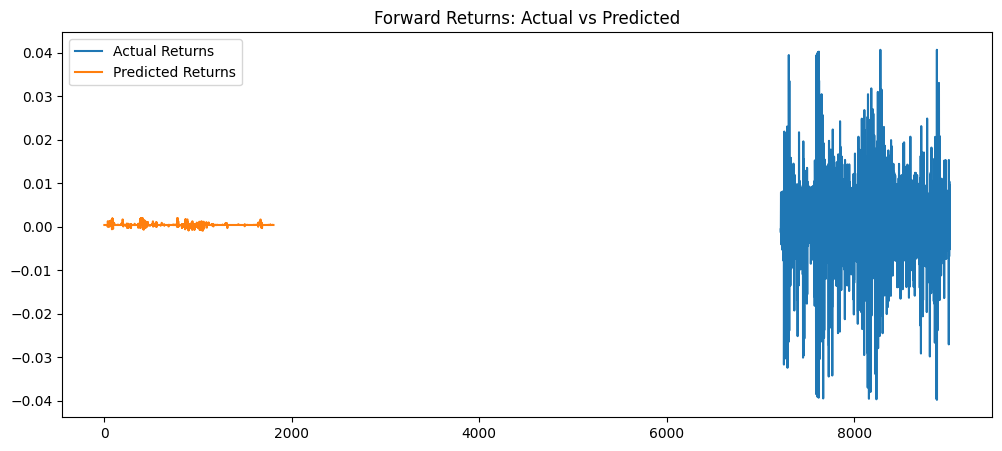

In [201]:
plt.figure(figsize=(12,5))
plt.plot(true, label="Actual Returns")
plt.plot(pred, label="Predicted Returns")
plt.legend()
plt.title("Forward Returns: Actual vs Predicted")
plt.show()

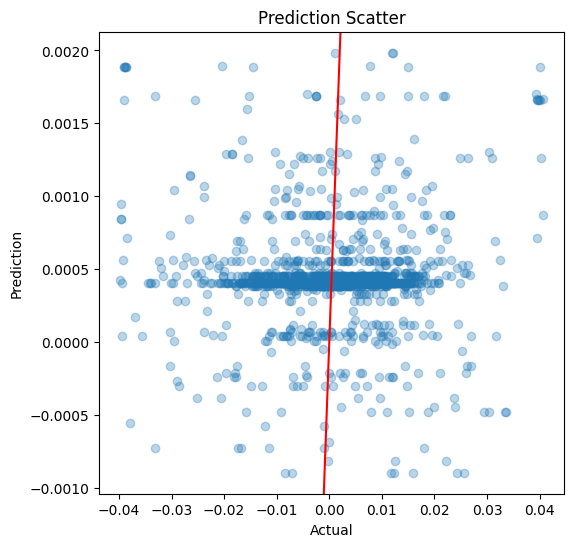

In [202]:
plt.figure(figsize=(6,6))
plt.scatter(true, pred, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Prediction")
plt.title("Prediction Scatter")
plt.axline((0, 0), slope=1, color="red")
plt.show()

# sharpe ratio

In [203]:
pred_dir = np.sign(pred)
strategy_return = pred_dir * true

sharpe = (strategy_return.mean() / strategy_return.std()) * np.sqrt(252)
print("Strategy Sharpe Ratio:", sharpe)

#

Strategy Sharpe Ratio: 0.5933749823567335


#cumulative returns

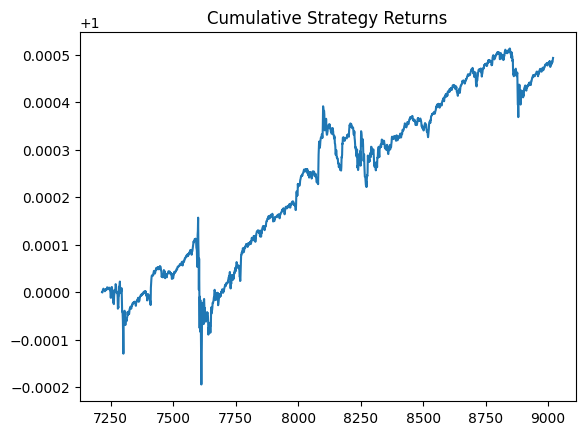

In [204]:
strategy_returns = preds_val * y_val
cum_returns = (1 + strategy_returns).cumprod()

plt.plot(cum_returns)
plt.title("Cumulative Strategy Returns")
plt.show()

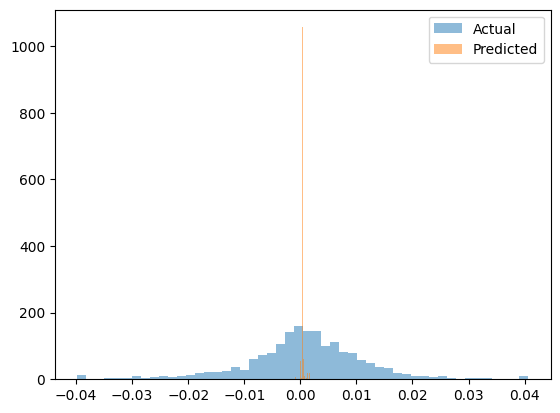

In [205]:
plt.hist(y_val, bins=50, alpha=0.5, label='Actual')
plt.hist(preds_val, bins=50, alpha=0.5, label='Predicted')
plt.legend()
plt.show()